<a href="https://colab.research.google.com/github/elinsyn/Fluid_mechanics/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# About the code

In [455]:
# Copyright (C) 2019 Johan Hoffman (jhoffman@kth.se)

# Setup environment

In [456]:
# Load neccessary modules.
from google.colab import files

import numpy as np
import time

# Install FEniCS (this may take a long time)
try:
    import dolfin
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/fenics-install-release-real.sh" -O "/tmp/fenics-install.sh" && bash "/tmp/fenics-install.sh"
    import dolfin

from dolfin import *; from mshr import *

import dolfin.common.plotting as fenicsplot

from matplotlib import pyplot as plt

# Define domain and mesh

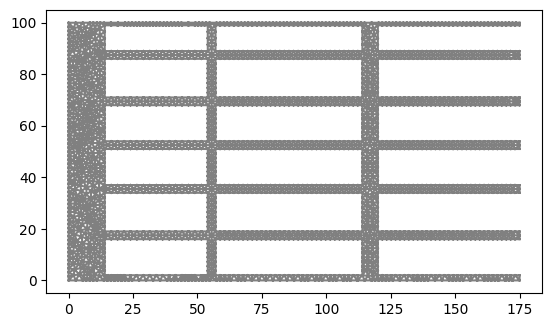

In [457]:
# Define domain
L = 175
H = 100

# Define subdomains
class Left(SubDomain):
    def inside(self, x, on_boundary):
        return near(x[0], 0.0)

class Right(SubDomain):
    def inside(self, x, on_boundary):
        return near(x[0], L)

class Lower(SubDomain):
    def inside(self, x, on_boundary):
        return near(x[1], 0.0)

class Upper(SubDomain):
    def inside(self, x, on_boundary):
        return near(x[1], H)

left = Left()
right = Right()
lower = Lower()
upper = Upper()

resolution = 64

# Generate mesh
domain = Rectangle(Point(0.0,0.0), Point(L,H))

# Manhattan
house1 = Polygon([Point(14,99),Point(14,89),Point(54,89),Point(54,99)])
house2 = Polygon([Point(14,86),Point(14,71),Point(54,71),Point(54,86)])
house3 = Polygon([Point(14,68),Point(14,54),Point(54,54),Point(54,68)])
house4 = Polygon([Point(14,51),Point(14,37),Point(54,37),Point(54,51)])
house5 = Polygon([Point(14,34),Point(14,19),Point(54,19),Point(54,34)])
house6 = Polygon([Point(14,16),Point(14,2),Point(54,2),Point(54,16)])

house7 = Polygon([Point(57,99),Point(57,89),Point(114,89),Point(114,99)])
house8 = Polygon([Point(57,86),Point(57,71),Point(114,71),Point(114,86)])
house9 = Polygon([Point(57,68),Point(57,54),Point(114,54),Point(114,68)])
house10 = Polygon([Point(57,51),Point(57,37),Point(114,37),Point(114,51)])
house11 = Polygon([Point(57,34),Point(57,19),Point(114,19),Point(114,34)])
house12 = Polygon([Point(57,16),Point(57,2),Point(114,2),Point(114,16)])

house13 = Polygon([Point(120,99),Point(120,89),Point(175,89),Point(175,99)])
house14 = Polygon([Point(120,86),Point(120,71),Point(175,71),Point(175,86)])
house15 = Polygon([Point(120,68),Point(120,54),Point(175,54),Point(175,68)])
house16 = Polygon([Point(120,51),Point(120,37),Point(175,37),Point(175,51)])
house17 = Polygon([Point(120,34),Point(120,19),Point(175,19),Point(175,34)])
house18 = Polygon([Point(120,16),Point(120,2),Point(175,2),Point(175,16)])

manhattan = generate_mesh(domain - house1- house2- house3- house4 -house5-house6 - house7- house8- house9- house10 -house11-house12- house13- house14- house15- house16 -house17-house18, resolution)

mesh = manhattan

# Refine mesh
no_levels = 0
for i in range(0,no_levels):
  cell_marker = MeshFunction("bool", mesh, mesh.topology().dim())
  for cell in cells(mesh):
    cell_marker[cell] = False
    p = cell.midpoint()
    if p.distance(Point(0.5, 0.5)) < 1.0:
        cell_marker[cell] = True
  mesh = refine(mesh, cell_marker)

#plot(Q.mesh())

# Define mesh functions
boundaries = MeshFunction("size_t", mesh, mesh.topology().dim()-1)
boundaries.set_all(0)
left.mark(boundaries, 1)
right.mark(boundaries, 2)
lower.mark(boundaries, 3)
upper.mark(boundaries, 4)

plot(mesh)

# Define approximation spaces

In [458]:
# Generate finite element spaces
#VE = VectorElement("CG", mesh.ufl_cell(), 1)
#QE = FiniteElement("CG", mesh.ufl_cell(), 1)
#WE = VE * QE

#W = FunctionSpace(mesh, WE)
#V = FunctionSpace(mesh, VE)
#Q = FunctionSpace(mesh, QE)

V = VectorFunctionSpace(mesh, "Lagrange", 1)
Q = FunctionSpace(mesh, "Lagrange", 1)
K = FunctionSpace(mesh, "Discontinuous Lagrange", 0)

# Define trial and test functions
#(u, p) = TrialFunctions(W)
#(v, q) = TestFunctions(W)
u = TrialFunction(V)
p = TrialFunction(Q)
v = TestFunction(V)
q = TestFunction(Q)

# Define boundary conditions

In [459]:
class DirichletBoundaryLower(SubDomain):
    def inside(self, x, on_boundary):
        return (
            on_boundary
            and near(x[1], 0.0)
            and not near(x[0], 0.0)
            and not near(x[0], L)
        )

class DirichletBoundaryUpper(SubDomain):
    def inside(self, x, on_boundary):
        return (
            on_boundary
            and near(x[1], H)
            and not near(x[0], 0.0)
            and not near(x[0], L)
        )

class DirichletBoundaryLeft(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and near(x[0], 0.0)

class DirichletBoundaryRight(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and near(x[0], L)

class DirichletBoundaryObjects(SubDomain):
    def inside(self, x, on_boundary):
        return (
            on_boundary
            and not near(x[0], 0.0)
            and not near(x[0], L)
            and not near(x[1], 0.0)
            and not near(x[1], H)
        )


tol = 1e-8

# Use the same gaps you used when moving houses away from boundaries
top_gap = 2.0
right_gap = 2.0

# Store houses as rectangles: (xmin, xmax, ymin, ymax)
houses = [
    (14, 54, 89, 99),
    (14, 54, 71, 86),
    (14, 54, 54, 68),
    (14, 54, 37, 51),
    (14, 54, 19, 34),
    (14, 54, 2, 16),

    (57, 114, 89, 99),
    (57, 114, 71, 86),
    (57, 114, 54, 68),
    (57, 114, 37, 51),
    (57, 114, 19, 34),
    (57, 114, 2, 16),

    (120, 174, 89, 99),
    (120, 174, 71, 86),
    (120, 174, 54, 68),
    (120, 174, 37, 51),
    (120, 174, 19, 34),
    (120, 174, 2, 16),
]


class ObjectVerticalWalls(SubDomain):
    def inside(self, x, on_boundary):
        if not on_boundary:
            return False

        # Avoid outer domain boundaries
        if near(x[0], 0.0) or near(x[0], L) or near(x[1], 0.0) or near(x[1], H):
            return False

        for xmin, xmax, ymin, ymax in houses:
            on_left_or_right = near(x[0], xmin) or near(x[0], xmax)
            within_height = x[1] >= ymin - tol and x[1] <= ymax + tol

            if on_left_or_right and within_height:
                return True

        return False


class ObjectHorizontalWalls(SubDomain):
    def inside(self, x, on_boundary):
        if not on_boundary:
            return False

        # Avoid outer domain boundaries
        if near(x[0], 0.0) or near(x[0], L) or near(x[1], 0.0) or near(x[1], H):
            return False

        for xmin, xmax, ymin, ymax in houses:
            on_bottom_or_top = near(x[1], ymin) or near(x[1], ymax)
            within_width = x[0] >= xmin - tol and x[0] <= xmax + tol

            if on_bottom_or_top and within_width:
                return True

        return False


dbc_lower = DirichletBoundaryLower()
dbc_upper = DirichletBoundaryUpper()
dbc_left = DirichletBoundaryLeft()
dbc_right = DirichletBoundaryRight()

dbc_obj_vert = ObjectVerticalWalls()
dbc_obj_horz = ObjectHorizontalWalls()

uin = 1.0

# Inlet
bcu_in0 = DirichletBC(V.sub(0), uin, dbc_left)
bcu_in1 = DirichletBC(V.sub(1), 0.0, dbc_left)

# Upper wall: slip condition
bcu_upp1 = DirichletBC(V.sub(1), 0.0, dbc_upper)

# Lower wall: slip condition
bcu_low1 = DirichletBC(V.sub(1), 0.0, dbc_lower)

# Object slip condition
# Vertical house walls: normal direction is x-direction, so set u_x = 0
bcu_obj_vert = DirichletBC(V.sub(0), 0.0, dbc_obj_vert)

# Horizontal house walls: normal direction is y-direction, so set u_y = 0
bcu_obj_horz = DirichletBC(V.sub(1), 0.0, dbc_obj_horz)

# Pressure outlet
pout = 0.0
bcp1 = DirichletBC(Q, pout, dbc_right)

bcu = [bcu_in0, bcu_in1,
       bcu_upp1,
       bcu_low1,
       bcu_obj_vert,
       bcu_obj_horz]

bcp = [bcp1]

# Define model parameters

In [460]:
# Set permeability matrix
Kinv11 = Expression('100.0*fabs(sin(2.0*pi*(x[1] - 0.1*x[0])))', element = K.ufl_element())
Kinv12 = Expression('0.0', element = K.ufl_element())
Kinv21 = Kinv12
Kinv22 = Kinv11

# Set viscosity
nu = 1.0e-2

# Set effective viscosity
nueff = 1.0e-2

# Define method parameters

In [461]:
# Define functions
u0 = Function(V)
u1 = Function(V)
p0 = Function(Q)
p1 = Function(Q)

# Set method parameters
num_nnlin_iter = 5
prec = "amg" if has_krylov_solver_preconditioner("amg") else "default"

# Time step length
dt = 0.5*mesh.hmin()

# Define measure for boundary integration
ds = Measure('ds', domain=mesh, subdomain_data=boundaries)

# Define varitional problem

In [462]:
# Define variational problems
#d1 = 1.0*mesh.hmin()
#d2 = 1.0*mesh.hmin()
#d3 = 1.0e-2*mesh.hmin()

h = CellDiameter(mesh);
u_mag = sqrt(dot(u1,u1))
d1 = 1.0/sqrt((pow(1.0/dt,2.0) + pow(u_mag/h,2.0)))
#d1 = h
#d2 = 0.0
d2 = h*u_mag

um = 0.5*(u + u0)
um1 = 0.5*(u1 + u0)
Fu = inner((u - u0)/dt + grad(um)*um1, v)*dx - p1*div(v)*dx + nueff*inner(grad(um), grad(v))*dx \
    + d1*inner((u - u0)/dt + grad(um)*um1 + grad(p1), grad(v)*um1)*dx + d2*div(um)*div(v)*dx \
    + nu*(Kinv11*inner(um[0],v[0])*dx + Kinv12*inner(um[0],v[1])*dx + Kinv21*inner(um[1],v[0])*dx + Kinv22*inner(um[1],v[1])*dx)
au = lhs(Fu)
Lu = rhs(Fu)

Fp = d1*inner((u1 - u0)/dt + grad(um1)*um1 + grad(p), grad(q))*dx + div(um1)*q*dx
ap = lhs(Fp)
Lp = rhs(Fp)

# Assemble linear matrix
# Ap = assemble(ap)

# Set I/O variables

In [463]:
# Open files
file_u = File("results-BNS/u.pvd")
file_p = File("results-BNS/p.pvd")

# Set plot frequency
plot_time = 0
plot_freq = 10

# Time stepping algorithm

Time t = 0.625


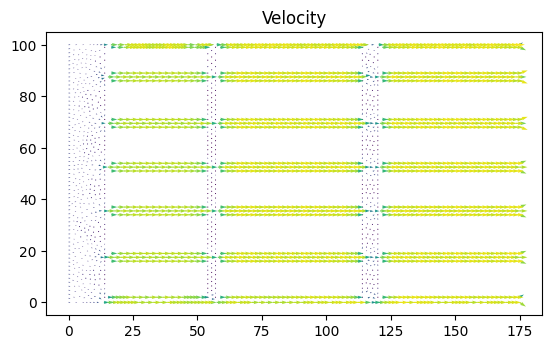

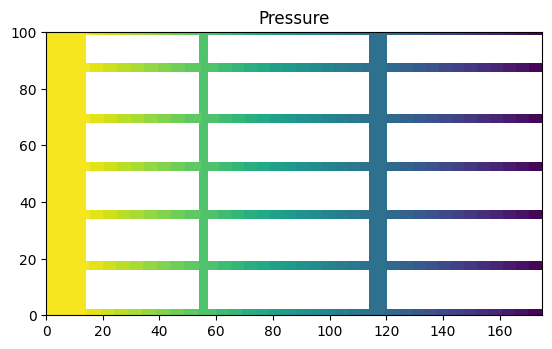

Time t = 1.25


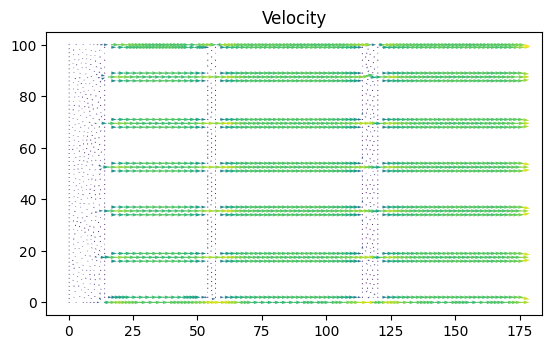

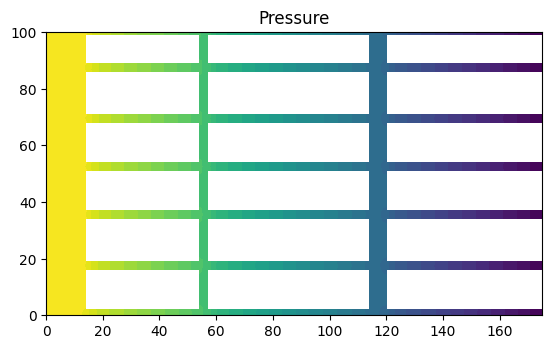

Time t = 2.5


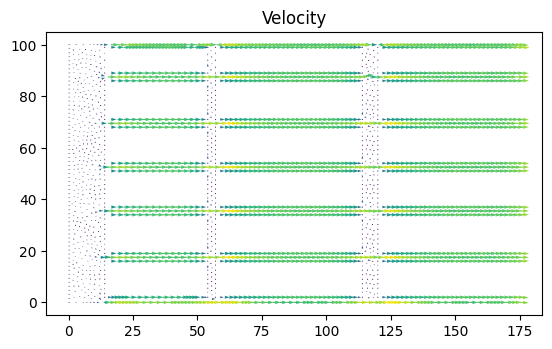

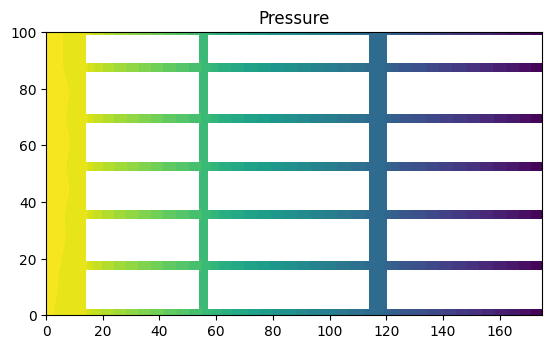

Time t = 3.125


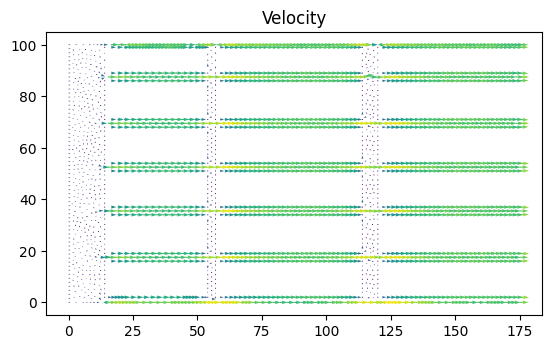

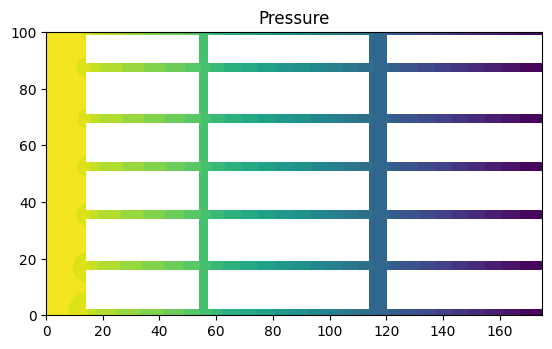

Time t = 4.375


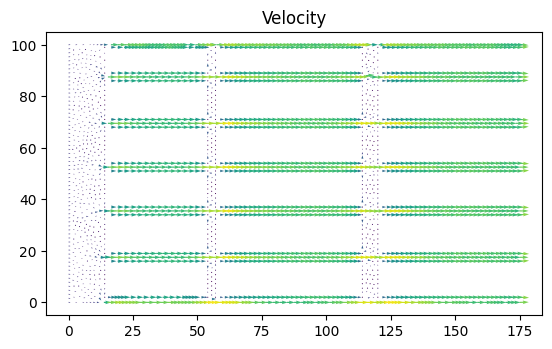

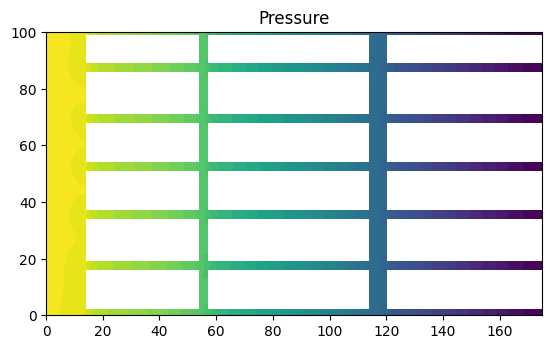

Time t = 5.625


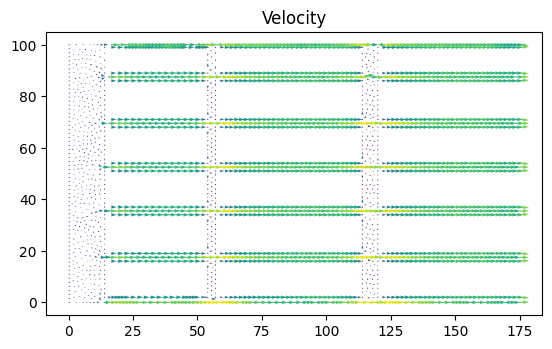

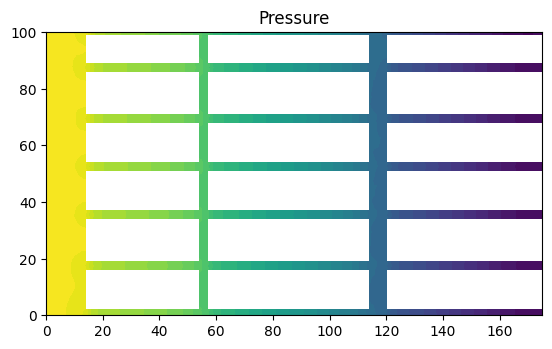

Time t = 6.25


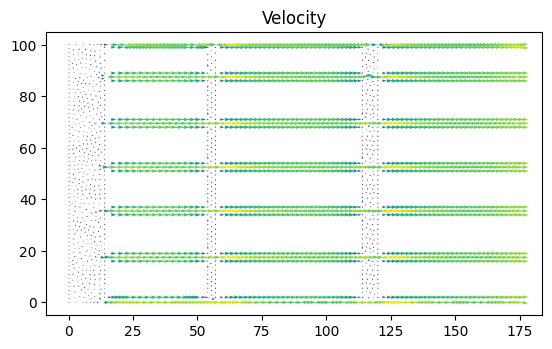

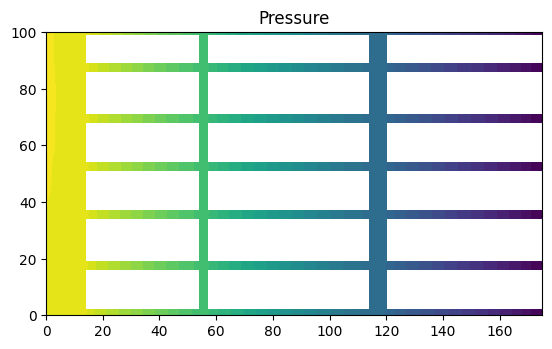

Time t = 7.5


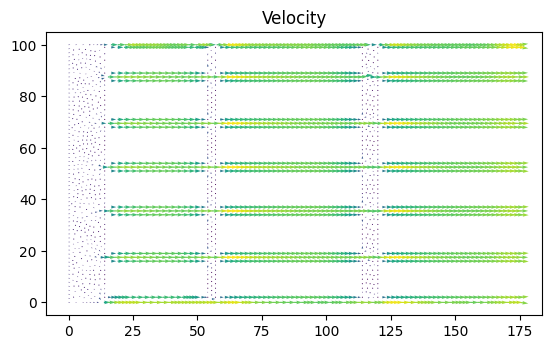

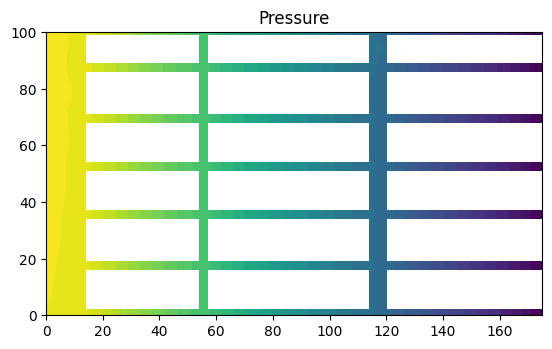

Time t = 8.125


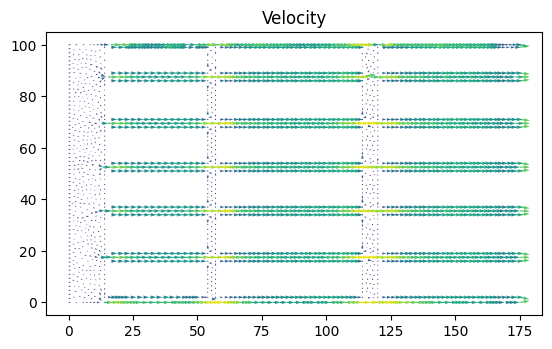

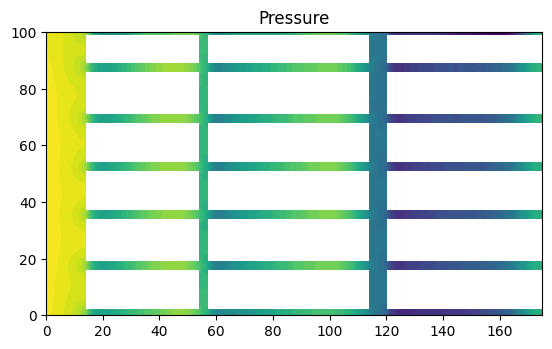

Time t = 9.375


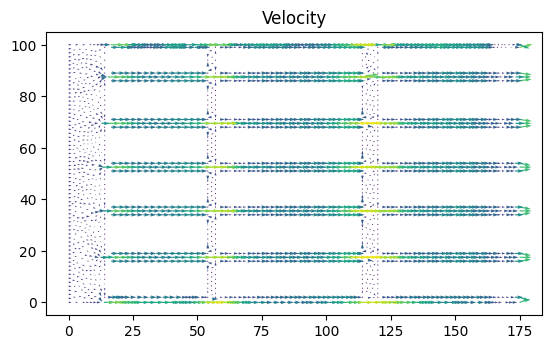

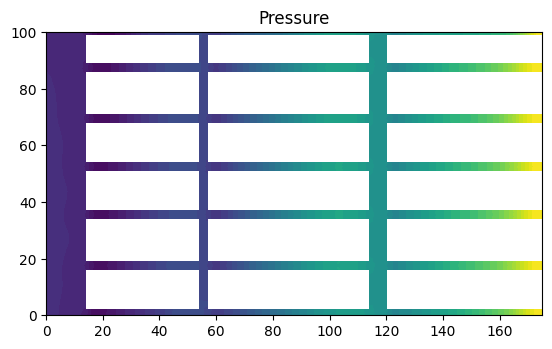

In [464]:
!rm results-BNS/*

# Time stepping
T = 10
t = dt
while t < T + DOLFIN_EPS:

    #s = 'Time t = ' + repr(t)
    #print(s)

    pin.t = t

    # Solve non-linear problem
    k = 0
    while k < num_nnlin_iter:

        # Assemble matrix and vector
        Au = assemble(au)
        bu = assemble(Lu)

        # Compute solution
        [bc.apply(Au, bu) for bc in bcu]
        [bc.apply(u1.vector()) for bc in bcu]
        solve(Au, u1.vector(), bu, "bicgstab", "default")

        # Assemble matrix and vector
        Ap = assemble(ap)
        bp = assemble(Lp)

        # Compute solution
        [bc.apply(Ap, bp) for bc in bcp]
        [bc.apply(p1.vector()) for bc in bcp]
        solve(Ap, p1.vector(), bp, "bicgstab", prec)

        k += 1

    if t > plot_time:

        s = 'Time t = ' + repr(t)
        print(s)

        # Save solution to file
        file_u << u1
        file_p << p1

        # Plot solution
        plt.figure()
        plot(u1, title="Velocity")

        plt.figure()
        plot(p1, title="Pressure")

        plot_time += T/plot_freq

        plt.show()

    # Update time step
    u0.assign(u1)
    t += dt

plt.show()

#!tar -czvf results-BNS.tar.gz results-BNS
#files.download('results-BNS.tar.gz')